## Ionospheric Gradient Calculation for BOI correction.

In [7]:
##This is all necearry function to run the notebook effectively
from functions_for_report import *
import seaborn as sns
sns.set_context("paper")
# plt.style.use('default')  #

In [2]:
####Sample date for correction
frame='116A_05207_252525'
epoch='20160124'
metadir = os.path.join('/gws/nopw/j04/nceo_geohazards_vol1/public/LiCSAR_products', str(int(frame[:3])), frame, 'metadata')
metafile = os.path.join(metadir,'metadata.txt')
master=str(grep1line('master',metafile).split('=')[1])
try:
    centre_range_m = float(grep1line('centre_range_ok_m',metafile).split('=')[1]) # 2024: GAMMA had a bug wrongly informing on centre_range (may differ by 20 km or so!). fixed most of it
except:
    centre_range_m=float(grep1line('centre_range_m',metafile).split('=')[1])
center_time=grep1line('center_time',metafile).split('=')[1]
acqtime = pd.to_datetime(str(epoch) + 'T' + center_time)

### 1. Obtain TEC Maps from CODE GIM or JPL

In the standard LiCSBAS workflow, we retrieve TEC (Total Electron Content) maps using the following function to calculate the ionospheric correction:

```python
tecxr = get_vtec_from_code(acqtime, lat=0, lon=0, return_fullxr=True)
```
This function downloads IONEX data from the CODE GIM dataset, typically stored in:  
<span style="color:blue">/gws/nopw/j04/nceo_geohazards_vol1/code_iono/</span>


In [3]:
!ls -lh /gws/nopw/j04/nceo_geohazards_vol1/code_iono/ | head -n 5

total 81G
-rw-rw-r-- 1 earmla   gws_nceo_geohazards 1.7M Jan 12  2023 COD0OPSFIN_20223310000_01D_01H_GIM.INX
-rw-rw-r-- 1 earmla   gws_nceo_geohazards 1.7M Jan 12  2023 COD0OPSFIN_20223320000_01D_01H_GIM.INX
-rw-rw-r-- 1 earmla   gws_nceo_geohazards 1.7M Jan 12  2023 COD0OPSFIN_20223330000_01D_01H_GIM.INX
-rw-rw-r-- 1 earmla   gws_nceo_geohazards 1.7M Jan 12  2023 COD0OPSFIN_20223340000_01D_01H_GIM.INX
ls: write error: Broken pipe


These INX (IONEX) files are text-based data files that provide daily global TEC (Total Electron Content) variations, sampled hourly. The spatial resolution of the TEC maps is approximately **2.5° (latitude) × 5.0° (longitude)**.

For a single day, the TEC data consists of **24 hourly epochs**, and the corresponding `xarray.DataArray` typically has the following shape:



In [4]:
##The one day epoch for 2016-01-30 dates low resolution TEC variation from CODE-GIM 
tecxr=get_vtec_from_code(acqtime, lat=0, lon=0, return_fullxr = True, noJPL=True)

In [5]:
tecxr

<xarray.DataArray (time: 25, lat: 71, lon: 73)>
array([[[  2.50000000e+16,   2.50000000e+16,   2.50000000e+16, ...,
           2.50000000e+16,   2.50000000e+16,   2.50000000e+16],
        [  2.80000000e+16,   2.80000000e+16,   2.80000000e+16, ...,
           2.80000000e+16,   2.80000000e+16,   2.80000000e+16],
        [  2.80000000e+16,   2.80000000e+16,   2.90000000e+16, ...,
           2.80000000e+16,   2.80000000e+16,   2.80000000e+16],
        ..., 
        [  1.44000000e+17,   1.45000000e+17,   1.44000000e+17, ...,
           1.43000000e+17,   1.44000000e+17,   1.44000000e+17],
        [  1.20000000e+17,   1.20000000e+17,   1.20000000e+17, ...,
           1.20000000e+17,   1.20000000e+17,   1.20000000e+17],
        [  1.00000000e+17,   1.00000000e+17,   1.00000000e+17, ...,
           1.00000000e+17,   1.00000000e+17,   1.00000000e+17]],

       [[  3.30000000e+16,   3.30000000e+16,   3.30000000e+16, ...,
           3.30000000e+16,   3.30000000e+16,   3.30000000e+16],
        [  3.70000000e+16,   3.80000000e+16,   3.80000000e+16, ...,
           3.70000000e+16,   3.70000000e+16,   3.70000000e+16],
        [  3.90000000e+16,   4.00000000e+16,   4.10000000e+16, ...,
           3.70000000e+16,   3.80000000e+16,   3.90000000e+16],
...
        [  1.50000000e+17,   1.53000000e+17,   1.55000000e+17, ...,
           1.45000000e+17,   1.48000000e+17,   1.50000000e+17],
        [  1.40000000e+17,   1.41000000e+17,   1.43000000e+17, ...,
           1.37000000e+17,   1.39000000e+17,   1.40000000e+17],
        [  1.32000000e+17,   1.32000000e+17,   1.33000000e+17, ...,
           1.30000000e+17,   1.31000000e+17,   1.32000000e+17]],

       [[  4.70000000e+16,   4.70000000e+16,   4.70000000e+16, ...,
           4.70000000e+16,   4.70000000e+16,   4.70000000e+16],
        [  4.90000000e+16,   5.00000000e+16,   5.00000000e+16, ...,
           4.80000000e+16,   4.80000000e+16,   4.90000000e+16],
        [  4.90000000e+16,   5.00000000e+16,   5.20000000e+16, ...,
           4.70000000e+16,   4.80000000e+16,   4.90000000e+16],
        ..., 
        [  1.56000000e+17,   1.58000000e+17,   1.59000000e+17, ...,
           1.51000000e+17,   1.54000000e+17,   1.56000000e+17],
        [  1.39000000e+17,   1.40000000e+17,   1.41000000e+17, ...,
           1.36000000e+17,   1.38000000e+17,   1.39000000e+17],
        [  1.23000000e+17,   1.24000000e+17,   1.24000000e+17, ...,
           1.22000000e+17,   1.23000000e+17,   1.23000000e+17]]])
Coordinates:
  * time     (time) float64 0.0 1.0 2.0 3.0 4.0 5.0 ... 20.0 21.0 22.0 23.0 24.0
  * lon      (lon) float64 -180.0 -175.0 -170.0 -165.0 ... 170.0 175.0 180.0
  * lat      (lat) float64 87.5 85.0 82.5 80.0 77.5 ... -80.0 -82.5 -85.0 -87.5

##### a. CODE GIM TEC Variation

This dataset provides **hourly TEC variation**, with each epoch representing the global TEC map at a one-hour interval. The spatial resolution is approximately:

- **2.5° in latitude**
- **5.0° in longitude**

This results in **25 time steps per day**, and each TEC map has the following shape:


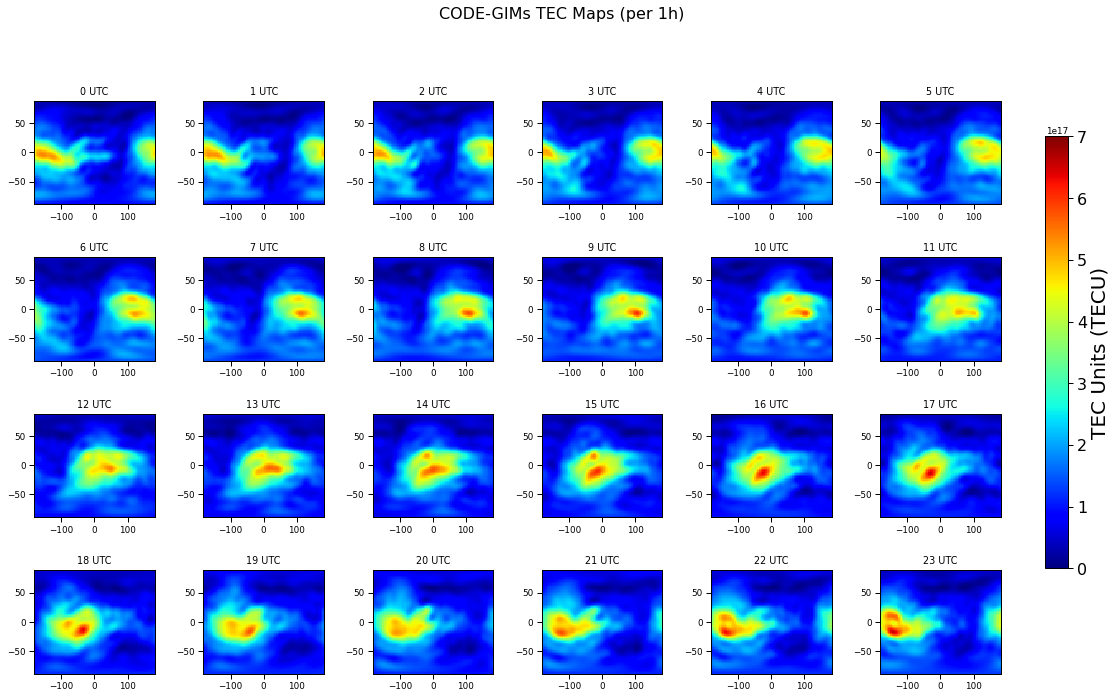

In [16]:
# Define the figure and axes (4 rows, 6 columns)
# Set global font size
plt.rcParams.update({'font.size': 20})
fig, axes = plt.subplots(4, 6, figsize=(16, 10))

# Adjust layout
fig.suptitle("CODE-GIMs TEC Maps (per 1h)", fontsize=16)

# Determine vmin and vmax for a consistent color scale
vmin = tecxr.min().values
vmax = tecxr.max().values

# Loop through time steps and plot on subplots
for i, ax in enumerate(axes.flat):
    if i < len(tecxr.time):
        # Select the TEC map at time `i`
        tecxr_selected = tecxr.sel(time=tecxr.time[i])

        # Plot on the current axis with fixed vmin/vmax
        im = tecxr_selected.plot(ax=ax, cmap='jet', add_colorbar=False, vmin=0, vmax=7e17)
        
        # Set title as time step
        ax.set_title(f"{int(tecxr.time[i].values)} UTC")
        
        # Remove axis labels for cleaner visualization
        ax.set_xlabel("")
        ax.set_ylabel("")
    else:
        ax.axis("off")  # Hide unused subplots if any

# Create a single colorbar
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)  # Assign the colorbar object
cbar.set_label("TEC Units (TECU)", fontsize=20)
cbar.ax.tick_params(labelsize=16)

# Set the colorbar range from 0 to 7e17
im.set_clim(0, 7e17)  # Correct method to apply limits

# Adjust spacing
plt.tight_layout(rect=[0, 0, 0.9, 0.95])  # Leave space for the colorbar
plt.savefig('CODE-GIMs TEC.png', dpi=900)


#### b. JPL High-Resolution TEC Maps

The JPL high-resolution dataset provides global TEC values with:

- **Temporal resolution:** 15-minute intervals (i.e., 96 epochs per day)
- **Spatial resolution:** 1.0° × 1.0° (latitude × longitude)

In [7]:
!ls -lh /gws/nopw/j04/nceo_geohazards_vol1/code_iono/ | tail -n 5

-rw-rw-r-- 1 mnergiz  gws_nceo_geohazards  30M Apr 21  2023 jpld3650.20i.nc
-rw-rw-r-- 1 mnergiz  gws_nceo_geohazards  30M Apr 21  2023 jpld3650.21i.nc
-rw-rw-r-- 1 mnergiz  gws_nceo_geohazards  30M Apr 21  2023 jpld3650.22i.nc
-rw-rw-r-- 1 mnergiz  gws_nceo_geohazards  30M Apr  8  2024 jpld3650.23i.nc
-rw-rw-r-- 1 mnergiz  gws_nceo_geohazards  30M Mar 15  2023 jpld3660.16i.nc


the typical shape of the JPL-HR `xarray.DataArray` is:

In [18]:
##The one day epoch for 2016-01-30 dates high resolution TEC variation from JPL-HR 
tecxr_hr=get_vtec_from_code(acqtime, lat=0, lon=0, return_fullxr = True, noJPL=False)

In [19]:
tecxr_hr

<xarray.DataArray (time: 96, lat: 180, lon: 360)>
array([[[  1.00000005e+15,   1.00000005e+15,   1.00000005e+15, ...,
           1.00000005e+15,   1.00000005e+15,   1.00000005e+15],
        [  3.00000030e+15,   3.00000030e+15,   3.00000030e+15, ...,
           3.00000030e+15,   3.00000030e+15,   3.00000030e+15],
        [  6.00000059e+15,   6.00000059e+15,   6.00000059e+15, ...,
           6.00000059e+15,   6.00000059e+15,   6.00000059e+15],
        ..., 
        [  1.13000005e+17,   1.13000005e+17,   1.13000005e+17, ...,
           1.13000005e+17,   1.13000005e+17,   1.13000005e+17],
        [  1.08000002e+17,   1.08000002e+17,   1.08000002e+17, ...,
           1.08000002e+17,   1.08000002e+17,   1.08000002e+17],
        [  1.03000007e+17,   1.03000007e+17,   1.03000007e+17, ...,
           1.03000007e+17,   1.03000007e+17,   1.03000007e+17]],

       [[  3.00000030e+15,   3.00000030e+15,   3.00000030e+15, ...,
           3.00000030e+15,   3.00000030e+15,   3.00000030e+15],
        [  6.00000059e+15,   6.00000059e+15,   6.00000059e+15, ...,
           6.00000059e+15,   6.00000059e+15,   6.00000059e+15],
        [  8.99999982e+15,   8.99999982e+15,   8.99999982e+15, ...,
           8.99999982e+15,   8.99999982e+15,   8.99999982e+15],
...
        [  1.33000002e+17,   1.33999999e+17,   1.33999999e+17, ...,
           1.33000002e+17,   1.33000002e+17,   1.33000002e+17],
        [  1.30000001e+17,   1.30000001e+17,   1.30000001e+17, ...,
           1.30000001e+17,   1.30000001e+17,   1.30000001e+17],
        [  1.26000004e+17,   1.26000004e+17,   1.26000004e+17, ...,
           1.26000004e+17,   1.26000004e+17,   1.26000004e+17]],

       [[  2.59999990e+16,   2.59999990e+16,   2.59999990e+16, ...,
           2.59999990e+16,   2.59999990e+16,   2.59999990e+16],
        [  2.79999999e+16,   2.79999999e+16,   2.79999999e+16, ...,
           2.79999999e+16,   2.79999999e+16,   2.79999999e+16],
        [  2.90000014e+16,   2.90000014e+16,   2.90000014e+16, ...,
           2.90000014e+16,   2.90000014e+16,   2.90000014e+16],
        ..., 
        [  1.31000007e+17,   1.31000007e+17,   1.31000007e+17, ...,
           1.31000007e+17,   1.31000007e+17,   1.31000007e+17],
        [  1.27000001e+17,   1.27000001e+17,   1.27000001e+17, ...,
           1.27000001e+17,   1.27000001e+17,   1.27000001e+17],
        [  1.24000001e+17,   1.24000001e+17,   1.24000001e+17, ...,
           1.23000004e+17,   1.24000001e+17,   1.24000001e+17]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2016-01-24 ... 2016-01-24T23:45:00
  * lat      (lat) float32 89.5 88.5 87.5 86.5 85.5 ... -86.5 -87.5 -88.5 -89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5


For the same date (**2016-01-30**), the JPL High-Resolution dataset provides TEC maps at **15-minute intervals**, resulting in **96 epochs** for the full day. Each map shows the global TEC distribution for a specific time step.

Below is a series of TEC snapshots over the day, visualized from the `tecxr_hr` dataset:


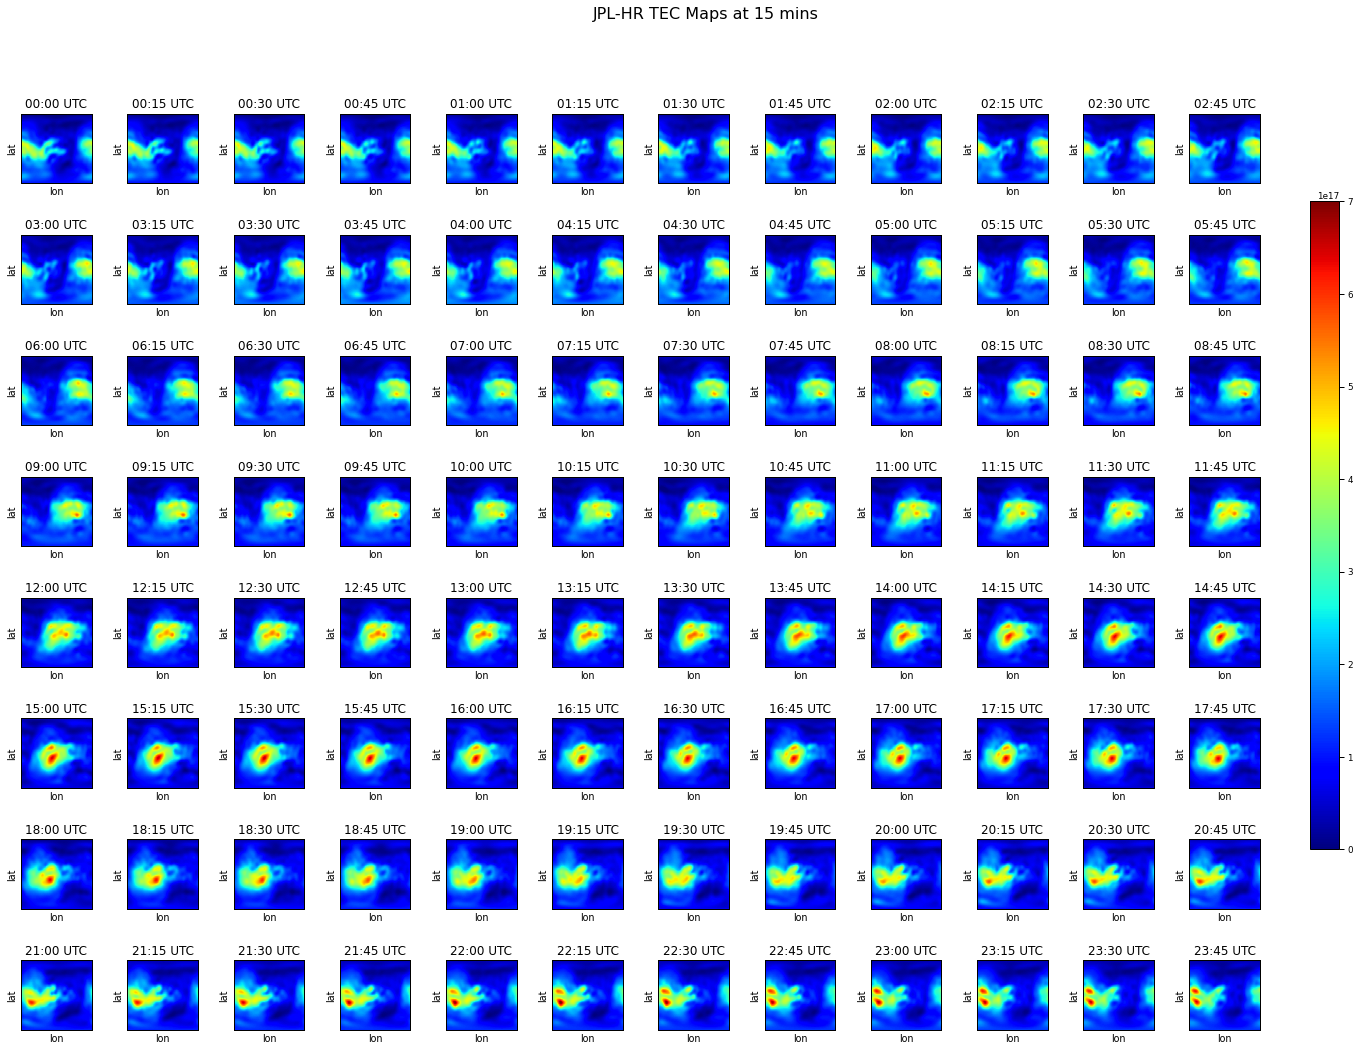

In [20]:
fig, axes = plt.subplots(8, 12, figsize=(20, 15))

# Adjust layout
fig.suptitle("JPL-HR TEC Maps at 15 mins", fontsize=16)

# Determine vmin and vmax for a consistent color scale
# Set consistent color scale limits
vmin = 0
vmax = 7e17

# Loop through each time step and plot
for i, ax in enumerate(axes.flat):
    if i < len(tecxr_hr.time):
        tec_slice = tecxr_hr.sel(time=tecxr_hr.time[i])
        im = tec_slice.plot(
            ax=ax,
            cmap='jet',
            add_colorbar=False,
            vmin=vmin,
            vmax=vmax
        )
        
        # Format time label
        time_str = pd.to_datetime(str(tecxr_hr.time[i].values)).strftime("%H:%M")
        ax.set_title(f"{time_str} UTC", fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
    else:
        ax.axis("off")

# Add shared colorbar
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
cbar = fig.colorbar(im, cax=cbar_ax)
# cbar.set_label("TEC Units (TECU)", fontsize=12)

# Adjust layout to leave space for title and colorbar
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


#### c. Comparing Hourly TEC Variations

To evaluate the consistency and resolution differences between datasets, we compare the **hourly TEC maps** from:



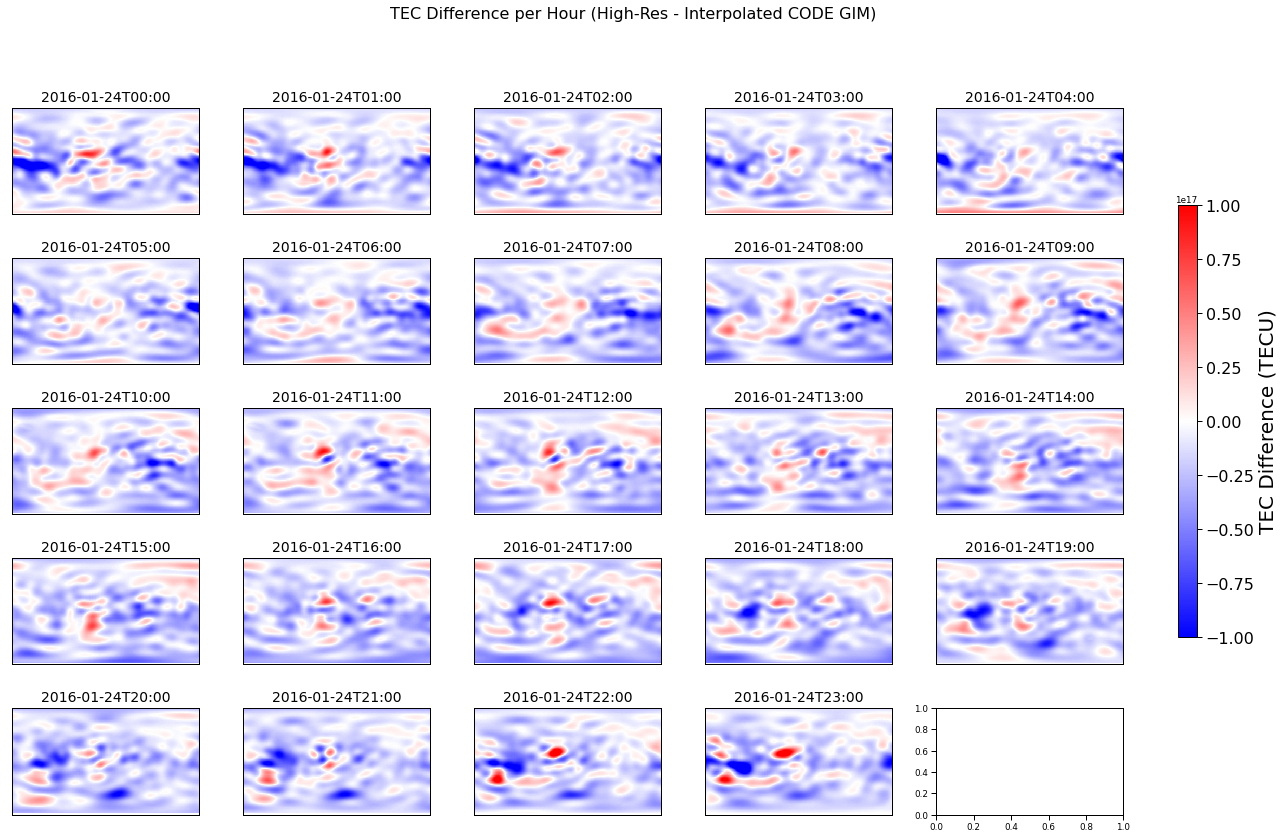

In [27]:
# Get hourly time indices from high-res (every 4th from 96)
selected_indices = range(0, 96, 4)
selected_times = tecxr_hr.time.values[selected_indices]

# Setup subplots: 5 rows × 5 columns
fig, axes = plt.subplots(5, 5, figsize=(18, 12))
fig.suptitle("TEC Difference per Hour (High-Res - Interpolated CODE GIM)", fontsize=16)

for idx, i in enumerate(selected_indices):
    ax = axes.flat[idx]
    
    # Intentionally skip the last one
    if idx == len(selected_indices):
        ax.axis("off")
        continue

    # Get low-res CODE map at current hour
    tecxr_da = tecxr.isel(time=idx)

    # Interpolate CODE to match high-res grid
    tecxr_interp = tecxr_da.interp_like(tecxr_hr.isel(time=i), method='linear')

    # Compute the difference (same shape as high-res)
    tec_difference = tecxr_hr.isel(time=i) - tecxr_interp

    # Plot the difference
    im = tec_difference.plot(
        ax=ax, cmap='bwr', add_colorbar=False, vmin=-1e17, vmax=1e17
    )
    ax.set_title(str(selected_times[idx])[:16], fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])

# Add a single colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("TEC Difference (TECU)", fontsize=20)
# cbar.set_label("TEC Units (TECU)", fontsize=20)
cbar.ax.tick_params(labelsize=16)

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.savefig('TEC_difference.png', dpi=300)


In [24]:
idx

23

### 2. Calculation of Ionospheric Gradient from TEC Maps

After retrieving global TEC maps, the next step is to estimate the **ionospheric gradient** at the coordinates of the SAR image pixels (target area). This process involves two key challenges:

1. **Spatial Resolution Mismatch:**
   - The spatial resolution of the TEC maps is:
     - **~250 km × 500 km** for **CODE GIM**
     - **~100 km × 100 km** for **JPL High-Resolution**
   - These resolutions are much coarser than SAR pixel sizes. Therefore, **spatial interpolation** is required to estimate TEC values at the exact geolocation of each pixel in the SAR scene.

2. **Temporal Resolution Mismatch:**
   - TEC values are available:
     - Hourly for CODE GIM
     - Every 15 minutes for JPL-HR
   - However, Sentinel-1 acquisitions are **not always on these time steps**. To get the correct TEC value at the acquisition time, we apply **temporal interpolation** across the nearest TEC epochs.

By performing both spatial and temporal interpolation, we obtain a estimate of the **Total Electron Content at the time and location of acquisition**, which is then used to compute the ionospheric delay gradient across the interferogram.


#### a. Accounting for Earth's Rotation Between TEC Maps and SAR Acquisition

When calculating ionospheric delay at the SAR signal's piercing point, it's important to consider the **Earth's rotation relative to the Sun**.

- TEC maps are defined in a **Sun-synchronous frame**, meaning they are effectively "fixed" relative to the Sun.
- However, the **Earth rotates 360° in 24 hours**, or **15° per hour**.
- As a result, for each second after the TEC epoch, the piercing point's **sub-solar longitude shifts** westward by:



- **Earth rotates 360° in 24 hours → 15° per hour**
- For each second after a TEC epoch, the piercing point moves west by approximately **0.00417°/s**
- Instead of manually computing this for each case, we can represent the longitudinal shift as a **linear time-based correction**

---

##### TEC Epoch Shift per Dataset

| Dataset    | Temporal Resolution | Shift per Epoch | 
|------------|---------------------|------------------|
| CODE GIM   | 1 hour              | 15.00°          |
| JPL HR     | 15 minutes          | 3.75°           |

---

##### Linear Fit Formula for Longitude Shift

For any acquisition time `t_acq` and TEC epoch time `t_tec`, we can estimate the required shift in longitude as:

```python
Δlon = (t_acq - t_tec).total_seconds() * 15 / 3600


#### b. Calculating the TEC Gradient in the Along-Track (Azimuth) Direction

In BOI (Burst Overlap Interferometry) or split-beam processing, the ionospheric effect manifests primarily through the **gradient of the TEC** in the **along-track (azimuth) direction**.

This is because the **forward-looking** and **backward-looking** signals follow slightly different **Line-of-Sight (LoS) paths** through the ionosphere. As a result:

- The two signals pass through **different ionospheric piercing points**
- If the ionosphere is not uniform (which it rarely is), the difference in TEC introduces a **differential phase delay**



#### c. Calculating Piercing Points and TEC Variations (Forward/Backward Looks)

To estimate the ionospheric gradient affecting the BOI interferogram, we first compute the **Total Electron Content (TEC)** at two distinct **piercing points**: one in the **backward-looking direction (A)** and one in the **forward-looking direction (B)**.

This is done through the following steps:

---

##### 1. Determine Local Geometry

For each multilooked pixel in the SAR scene:

- We retrieve the **local incidence angle**, azimuth **heading**, and **center acquisition time**.
- We compute the **elevation angle** and use it to trace a ray from the ground pixel to the satellite.
- This yields the **satellite ground-projected position** (`Psatg`), accounting for the real slant range and local viewing geometry.

---

##### 2. Estimate Satellite Position for BOI Azimuth Looks

The satellite position is displaced **± burst length / 2** in the azimuth direction to simulate the forward (B) and backward (A) azimuth views:

- `PsatgA`: backward-looking satellite position  
- `PsatgB`: forward-looking satellite position

This simulates the two slightly different signal paths taken by the split-aperture InSAR observation.

---

##### 3. Calculate IPP (Ionospheric Piercing Point)

We calculate the point where the radar signal intersects the assumed ionospheric layer (e.g., 450 km altitude):

- This is done by projecting the radar line-of-sight (LOS) from ground toward the ionosphere.
- We get the **initial IPP point (`Pippg`)**, representing the average line-of-sight.

---

##### 4. Displace the IPP for Azimuth Split Paths

To simulate BOI's azimuth diversity:

- We displace `Pippg` in azimuth by the full burst length to get:
  - `PippAt`: backward piercing track  
  - `PippBt`: forward piercing track

---

##### 5. Calculate Piercing Points A and B

We intersect the path between:
- Scene center ↔ satellite (A and B),
- With the IPP forward/backward line.

This gives us two final points:
- `PippA`: actual backward-looking piercing point
- `PippB`: actual forward-looking piercing point

---

##### 6. Interpolate TEC at A and B

We sample the global TEC map (`tecxr`) at `PippA` and `PippB` using bilinear, cubic, or quadratic spatial interpolation, depending on the desired accuracy.

To account for the Earth's rotation, we apply a manual linear interpolation in time between TEC maps. This includes a longitude shift of:
- **15° per hour** for CODE GIM
- **3.75° per 15 minutes** for JPL HR

This rotation-aware correction ensures that the TEC values reflect the correct sub-solar position at the acquisition time.

```python
ionoijA = get_vtec_from_tecxr(tecxr, acqtime, PippA.latitude_deg, PippA.longitude_deg, method=method, rotate=True)
ionoijB = get_vtec_from_tecxr(tecxr, acqtime, PippB.latitude_deg, PippB.longitude_deg, method=method, rotate=True)

**Note that TEC map of tecxr can be from JPL or CODE-GIM regarding previous step**


##### Code Implementation: Interpolating TEC at Piercing Points A and B

The following code demonstrates how the TEC values at the backward (`PippA`) and forward (`PippB`) piercing points are calculated, including spatial interpolation and rotation-aware time interpolation, as described above.


In [12]:
alpha=0.85
source='code'
ionosampling = 20000  # m  --- by default, 20 km sampling should be ok?
inc=get_inc_frame(frame)
avg_incidence_angle = float(inc.mean())
# get hgt # no need anymore (2023/08)
metadir = os.path.join(os.environ['LiCSAR_public'],str(int(frame[:3])),frame,'metadata')
metafile = os.path.join(metadir,'metadata.txt')
scene_center_lon = float(inc.lon.mean())
scene_center_lat = float(inc.lat.mean())
#
center_time=grep1line('center_time',metafile).split('=')[1]
heading=float(grep1line('heading',metafile).split('=')[1])
try:
    centre_range_m = float(grep1line('centre_range_ok_m',metafile).split('=')[1]) # 2024: GAMMA had a bug wrongly informing on centre_range (may differ by 20 km or so!). fixed most of it
except:
    centre_range_m=float(grep1line('centre_range_m',metafile).split('=')[1])
#
master=str(grep1line('master',metafile).split('=')[1])
#
acqtime = pd.to_datetime(str(epoch) + 'T' + center_time)
# this is to get point between sat and scene centre
theta = np.radians(avg_incidence_angle)
wgs84 = nv.FrameE(name='WGS84')
Pscene_center = wgs84.GeoPoint(latitude=scene_center_lat, longitude=scene_center_lon, degrees=True)
burst_len = 7100*2.758277 #approx. satellite velocity on the ground 7100 [m/s] * burst_interval [s]
###### do the satg_lat, lon
azimuthDeg = heading - 90  # yes, azimuth is w.r.t. N (positive to E)
elevationDeg = 90 - avg_incidence_angle  # this is to get the avg sat altitude/range
slantRange = centre_range_m
hiono = 450
hiono = hiono * 1000  # m
resolution = get_resolution(inc, in_m=True)  # just mean avg in both lon, lat should be ok
# how large area is covered
lonextent = len(inc.lon) * resolution
# so what is the multilook factor?
mlfactorlon = round(len(inc.lon) / (lonextent / ionosampling))
latextent = len(inc.lat) * resolution
mlfactorlat = round(len(inc.lat) / (latextent / ionosampling))
#hgtml = hgt.coarsen({'lat': mlfactorlat, 'lon': mlfactorlon}, boundary='trim').mean()
incml = inc.coarsen({'lat': mlfactorlat, 'lon': mlfactorlon}, boundary='trim').mean() ##downsampling prevents unnecesarry high-frequency noise.
# get range towards iono single-layer in the path to the satellite, consider hgt
# range2iono = (hiono - hgtml) / np.cos(np.radians(incml))
# get range towards iono single-layer in the path to the satellite, do not consider hgt
range2iono = hiono / np.cos(np.radians(incml))  ##IPP to ground in the slant range direction
slantRanges=slant_ranges(frame, master, range2iono)
earth_radius = 6378160  # m
ionoxrA = incml.copy(deep=True)
ionoxrB = incml.copy(deep=True)
tecxr=get_vtec_from_code(acqtime, lat=0, lon=0, return_fullxr = True)
tecxr = alpha * tecxr
print('getting TEC values sampled by {} km.'.format(str(round(ionosampling / 1000))))
methods=['linear', 'cubic', 'quadratic']
results_dict = {
    'linear': {},
    'cubic': {},
    'quadratic': {}
}
first_run_done = False  # just create quick IppA/B
for method in methods:
    if first_run_done:
        break
    for i in range(len(range2iono.lat.values)):
        if first_run_done:
            break
        # print(str(i) + '/' + str(len(range2iono.lat.values)))
        for j in range(len(range2iono.lon.values)):
            if first_run_done:
                break
            if ~np.isnan(incml.values[i, j]):
                # theta = float(np.radians(incml.values[i, j]))
                eledeg = float(90 - incml.values[i, j])
                #ground_scene
                ilat_ground, ilon_ground = range2iono.lat.values[i], range2iono.lon.values[j]
                ##satellite scene, we need to consider satellite scene again for BOI
                x, y, z = aer2ecef(azimuthDeg, eledeg, slantRanges.values[i,j], ilat_ground, ilon_ground, 0) #scene_alt) ### this is wrt ellipsoid! ##TODO rather than the center slant range near center and far range can be added! IDK it's effect.
                satg_lat, satg_lon, sat_alt = ecef2latlonhei(x, y, z) ##satellite scene is changed becasue of the elevation degree change along the range direction
                sat_alt_km = round(sat_alt / 1000)
                Psatg = wgs84.GeoPoint(latitude=satg_lat, longitude=satg_lon, degrees=True)
                #then get A', B' ##squint angle in azimuth direction lead that shift.
                PsatgA, _azimuth = Psatg.displace(distance=burst_len/2, azimuth=heading-180, method='ellipsoid', degrees=True)
                PsatgB, _azimuth = Psatg.displace(distance=burst_len/2, azimuth= heading, method='ellipsoid', degrees=True)
                
                ##IPP scene, 
                x, y, z = aer2ecef(azimuthDeg, eledeg, range2iono.values[i, j], ilat_ground, ilon_ground, 0) #range should be in meter
                ippg_lat, ippg_lon, ipp_alt = ecef2latlonhei(x, y, z)
                Pippg = wgs84.GeoPoint(latitude=ippg_lat, longitude=ippg_lon, degrees=True)
                #then get A', B'
                PippAt, _azimuth = Pippg.displace(distance=burst_len, azimuth=heading-180, method='ellipsoid', degrees=True) #We extend burst_len to cover the intersection area. theorically burst_length/2 ideal
                PippBt, _azimuth = Pippg.displace(distance=burst_len, azimuth= heading, method='ellipsoid', degrees=True)
    
                ##intersection, to make sure IPP coordinates found
                path_ipp = nv.GeoPath(PippAt, PippBt)
                Pscene_center = wgs84.GeoPoint(latitude=ilat_ground, longitude=ilon_ground, degrees=True)
                path_scene_satgA = nv.GeoPath(Pscene_center, PsatgA)
                path_scene_satgB = nv.GeoPath(Pscene_center, PsatgB)
                # these two points are the ones where we should get TEC
                PippA = path_ipp.intersect(path_scene_satgA).to_geo_point()
                PippB = path_ipp.intersect(path_scene_satgB).to_geo_point()
    
                if source=='code':
                    # print('code selected')
                    ionoijA = get_vtec_from_tecxr(tecxr, acqtime, PippA.latitude_deg, PippA.longitude_deg, method=method,rotate=True)
                    ionoijB = get_vtec_from_tecxr(tecxr, acqtime, PippB.latitude_deg, PippB.longitude_deg, method=method,rotate=True)
                else:
                    # print('iri selected')
                    ionoijA = get_tecs(PippA.latitude_deg, PippA.longitude_deg, sat_alt_km, [acqtime], False, source=source)[0]  ##TODO ask Milan why we set the sat_alt_km rather than ipp_alt when we apply IRI model? it select IPP itself?
                    ionoijB = get_tecs(PippB.latitude_deg, PippB.longitude_deg, sat_alt_km, [acqtime], False, source=source)[0]
    
                #VTEC2STEC        
                theta = float(np.radians(incml.values[i, j]))
                sin_thetaiono = earth_radius / (earth_radius + hiono) * np.sin(theta)
                ionoxrA.values[i, j] = ionoijA / np.sqrt(1 - sin_thetaiono ** 2)
                ionoxrB.values[i, j] = ionoijB / np.sqrt(1 - sin_thetaiono ** 2)
                
                ####
                azpix=14000
                PRF = 486.486
                k = 40.308193 # m^3 / s^2
                f0 = 5.4050005e9
                c = speed_of_light
                dfDC=4300
                fH = f0 + dfDC*0.5
                fL = f0 - dfDC*0.5
                tecovl=(ionoxrA/fH-ionoxrB/fL)
                iono_grad = 2*PRF*k/c/dfDC * tecovl #unitless
                iono_grad_mm=iono_grad*azpix #mm
                # Save results
                results_dict[method]['ionoxrA'] = ionoxrA.copy()
                results_dict[method]['ionoxrB'] = ionoxrB.copy()
                results_dict[method]['iono_grad_mm'] = iono_grad_mm.copy()
                first_run_done = True
                break
        

getting TEC values sampled by 20 km.


In [13]:
# # Save 
# ##You don't need to rerrun again and again!
# with open('results_dict_highres.pkl', 'wb') as f:
#     pickle.dump(results_dict, f)
# Load later
with open('results_dict_highres.pkl', 'rb') as f:
    restored_dict_high = pickle.load(f)

##### Illustrating Satellite and Target Positions with Piercing Points (A and B)

Let's illustrate a single example showing the satellite position, the ground target, and the corresponding ionospheric piercing points for the **backward (A)** and **forward (B)** looking directions.


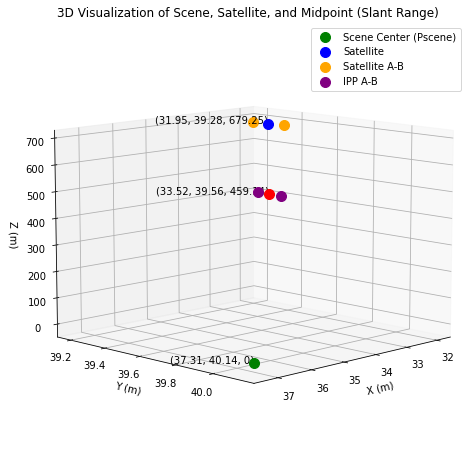

In [14]:
# Create 3D plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot scene center, satellite ground point, and midpoint
##ground
ax.scatter(ilon_ground, ilat_ground, 0, color='green', s=100, label="Scene Center (Pscene)")
# Annotate scene center
ax.text(ilon_ground, ilat_ground, 0, f"({ilon_ground:.2f}, {ilat_ground:.2f}, 0)", color='black', ha='right')

##satellite
ax.scatter(satg_lon, satg_lat, sat_alt/1000, color='blue', s=100, label="Satellite")

##SATAandB
ax.scatter(PsatgA.longitude_deg, PsatgA.latitude_deg, sat_alt/1000, color='orange', s=100, label='Satellite A-B')
ax.scatter(PsatgB.longitude_deg, PsatgB.latitude_deg, sat_alt/1000, color='orange', s=100)
# Annotate scene center
ax.text(satg_lon, satg_lat, sat_alt/1000, f"({satg_lon:.2f}, {satg_lat:.2f}, {sat_alt/1000:.2f})", color='black', ha='right')

# ##IPP
ax.scatter(ippg_lon, ippg_lat, ipp_alt/1000, color='red', s=100)
ax.text(ippg_lon, ippg_lat, ipp_alt/1000, f"({ippg_lon:.2f}, {ippg_lat:.2f}, {ipp_alt/1000:.2f})", color='black', ha='right')

# ##IPPA and B
ax.scatter(PippA.longitude_deg, PippA.latitude_deg, ipp_alt/1000, color='purple', s=100, label='IPP A-B')
ax.scatter(PippB.longitude_deg, PippB.latitude_deg, ipp_alt/1000, color='purple', s=100)


# Labels and view adjustments
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")
ax.set_title("3D Visualization of Scene, Satellite, and Midpoint (Slant Range)")
ax.legend()

# Adjust the view to rotate the X-axis toward the viewer
ax.view_init(elev=10, azim=45)  # Rotate azimuth to bring X-axis into view

# Show the plot
plt.show()


##### 3D Illustration of Satellite, Ground Scene, and Piercing Points

In the 3D plot above:

- The **green point** represents the scene center on the ground (`Pscene`).
- The **blue point** marks the satellite's position at the time of acquisition.
- The **orange points** indicate the satellite positions used for the **backward (A)** and **forward (B)** looks, based on azimuth displacement.
- The **red point** shows the average ionospheric piercing point (`IPP`) along the slant range.
- The **purple points** represent the **actual piercing points (A and B)** corresponding to the backward and forward azimuth directions.

These purple points are where we extract **TEC values from the global TEC maps**, which are essential for estimating the ionospheric gradient in the along-track direction.

---

### 3. TEC Map Resolution and Interpolation

The TEC maps are:

- **Hourly** with **2.5° × 5.0°** resolution for **CODE GIM**
- **Every 15 minutes** with **1° × 1°** resolution for **JPL High-Resolution**

Since the acquisition time of Sentinel-1 does not exactly match TEC map timestamps, we apply both:

- **Spatial interpolation** (e.g., linear, cubic) to get values at the precise piercing point coordinates
- **Temporal interpolation**, assuming **linear TEC variation** between two time steps

This is justified because:

- TEC changes relatively smoothly over short periods
- Linear time interpolation is used in other methods such as ETAD (External Tropospheric and Ionospheric Delay correction)

Regarding **Earth rotation**:

- For CODE GIM, TEC maps are 1 hour apart → Earth rotates **15°**, so a shift of up to 15° must be considered
- For JPL HR, the interval is 15 minutes → only **3.75°** rotation is involved

These rotation effects are linearly accounted for when interpolating in time to ensure TEC values are sampled at the correct sub-solar longitudes.


In [15]:
###

#### a. Ionospheric Effect on Along-Track Displacement

To estimate ionospheric distortion in BOI interferograms, we use the equation from Yagüe-Martínez et al. (2016):

$$
u_{\text{az,iono}} = \frac{2 \cdot \text{PRF} \cdot K}{c \cdot \Delta f_{\text{DC}}} \left( \frac{\Delta \text{TEC}_s(A)}{f_A} - \frac{\Delta \text{TEC}_s(B)}{f_B} \right) r_{\text{az}}
$$

This equation gives the ionosphere-induced **along-track displacement** based on the slant TEC difference between backward (A) and forward (B) looks.

- \( u_{\text{az,iono}} \): ionospheric-induced along-track displacement  
- PRF: Pulse Repetition Frequency  
- \( K \): physical constant (40.308193 m³/s²)  
- \( c \): speed of light  
- \( \Delta f_{\text{DC}} \): Doppler centroid bandwidth  
- \( \Delta \text{TEC}_s(A), \Delta \text{TEC}_s(B) \): slant TEC at backward and forward piercing points  
- \( f_A, f_B \): center frequencies for backward and forward looks  
- \( r_{\text{az}} \): azimuth pixel spacing

---

##### Simplified Gradient Expression

To analyze the ionospheric effect at a **single acquisition epoch** (rather than over an interferometric pair), we simplify the equation to isolate the instantaneous ionospheric gradient.

Assuming slant TEC values (\( \text{TEC}_A \), \( \text{TEC}_B \)) are available for the forward and backward looks of a single SAR acquisition, the ionospheric phase gradient in millimeters is computed as:

$$
\text{iono\_grad\_mm} = \frac{2 \cdot \text{PRF} \cdot K}{c \cdot \Delta f_{\text{DC}}} \left( \frac{\text{TEC}_A}{f_H} - \frac{\text{TEC}_B}{f_L} \right) r_{\text{az}}
$$

---

This approach allows us to estimate the **ionospheric contribution from a single SAR epoch**, making it easier to correct ionospheric distortion **either before forming an interferogram or after obtaining cumulative displacement from time series inversion**. 

It also enables **pixel-wise mapping of azimuthal ionospheric gradients** directly from TEC data, improving correction accuracy for both interferometric and time-series InSAR products.



You can run the code in **Section 2.c.6** by removing the break lines, which applies this method to compute the ionospheric gradient from TEC values at the backward and forward piercing points.

However, since the computation can be time-consuming, we also provide a pre-computed result saved in a **pickle file**, which can be loaded directly for visualization and analysis.


In [16]:
# Load later
with open('results_dict_highres.pkl', 'rb') as f:
    restored_dict_high = pickle.load(f)
# Load later
with open('results_dict_lowres.pkl', 'rb') as f:
    restored_dict_low = pickle.load(f)

In the loaded `restored_dict_high`, we store the results computed from the **JPL High-Resolution TEC maps**, using:

- **Three different spatial interpolation methods**: linear, cubic, and quadratic  
- **Linear interpolation in time**, accounting for Earth's rotation (3.75° per 15 minutes)

Each result includes:
- TEC values at backward and forward piercing points  
- The derived ionospheric gradient in millimeters

Let's now visualize these results to make the differences and gradient effects clearer.


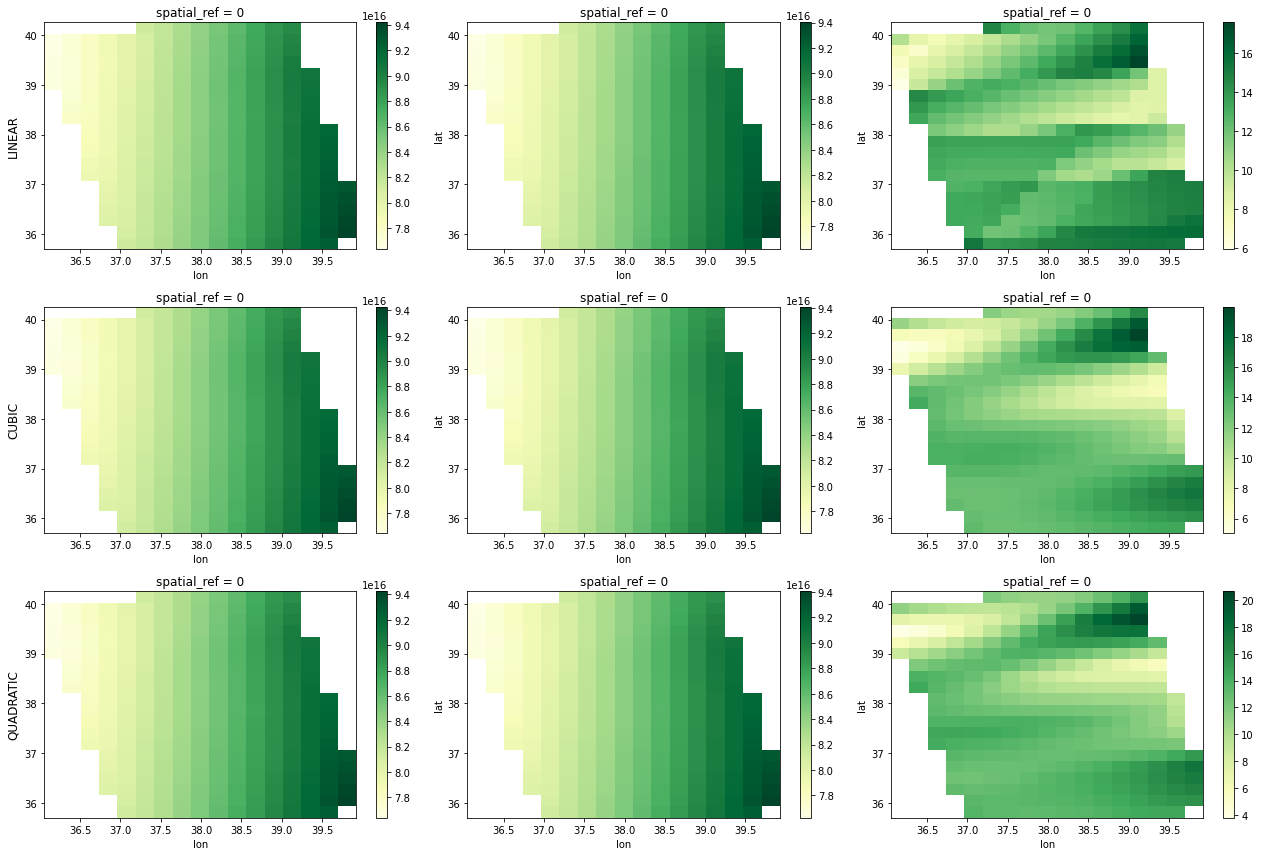

In [17]:
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
methods = ['linear', 'cubic', 'quadratic']
titles = ['TECA', 'TECB', 'Iono Correction (mm)']

for i, method in enumerate(methods):
    axs[i][0].set_title(titles[0])
    restored_dict_high[method]['ionoxrA'].plot(ax=axs[i][0], cmap='YlGn', add_colorbar=True)
    axs[i][1].set_title(titles[1])
    restored_dict_high[method]['ionoxrB'].plot(ax=axs[i][1], cmap='YlGn', add_colorbar=True)
    axs[i][2].set_title(titles[2])
    restored_dict_high[method]['iono_grad_mm'].plot(ax=axs[i][2], cmap='YlGn', add_colorbar=True)

    # Label rows
    axs[i][0].set_ylabel(method.upper(), fontsize=12)

plt.tight_layout()
plt.show()


As shown in the visualization, **linear interpolation in the spatial domain** introduces noticeable sharp transitions—particularly along the **latitude direction**.

Upon closer inspection, these artifacts appear at **1-degree intervals**, which directly corresponds to the **native spatial resolution of the JPL High-Resolution TEC maps** (1° × 1°). 

This indicates that **linear interpolation does not perform well at the borders of the TEC grid**, leading to artificial striping or discontinuities along grid lines.

Hence, for smoother and more physically realistic results, **higher-order spatial interpolation methods** (e.g., cubic or quadratic) are preferred when working with JPL-HR TEC data.


To confirm that these fluctuations are caused by spatial interpolation and not by actual ionospheric variation, let's compare the results with those calculated using **CODE GIM** TEC maps.

Since CODE GIM has a coarser resolution (2.5° × 5°) and different grid structure, any striping effect observed in JPL-HR results should not appear in the CODE-based estimates—assuming the interpolation is handled consistently.

By comparing both TEC values and the derived ionospheric gradient, we can validate whether the artifacts seen earlier are truly interpolation-related.


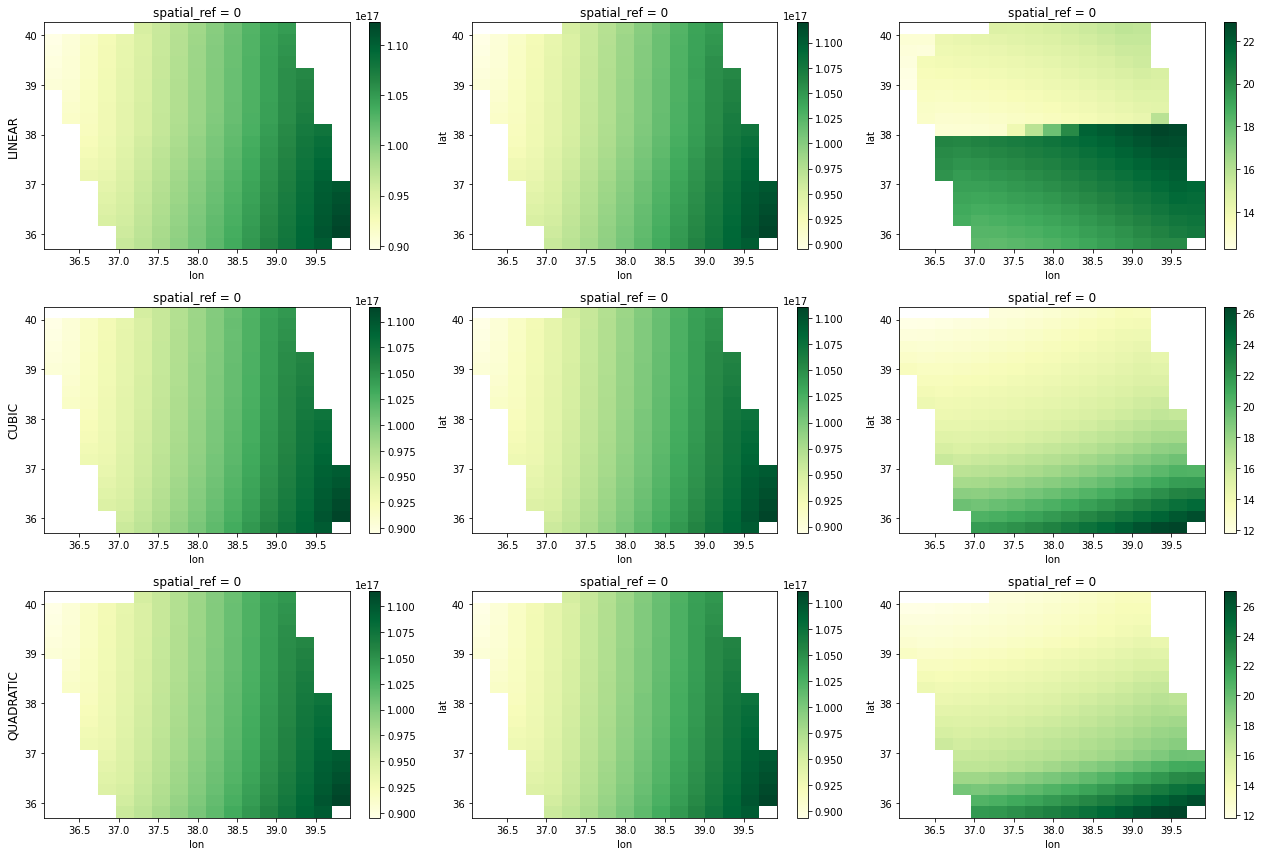

In [18]:
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
methods = ['linear', 'cubic', 'quadratic']
titles = ['TECA', 'TECB', 'Iono Correction (mm)']

for i, method in enumerate(methods):
    axs[i][0].set_title(titles[0])
    restored_dict_low[method]['ionoxrA'].plot(ax=axs[i][0], cmap='YlGn', add_colorbar=True)
    axs[i][1].set_title(titles[1])
    restored_dict_low[method]['ionoxrB'].plot(ax=axs[i][1], cmap='YlGn', add_colorbar=True)
    axs[i][2].set_title(titles[2])
    restored_dict_low[method]['iono_grad_mm'].plot(ax=axs[i][2], cmap='YlGn', add_colorbar=True)

    # Label rows
    axs[i][0].set_ylabel(method.upper(), fontsize=12)

plt.tight_layout()
plt.show()


As you can see in the results from CODE GIM, this time the sharp transitions appear along the **azimuth (latitude) direction**, and they occur approximately every **2.5 degrees**—which matches the spatial resolution of the CODE GIM maps.

This confirms that the artifacts are linked to the spatial resolution of the TEC grid and the interpolation method used.

For **cubic** and **quadratic** interpolation, these transitions are significantly smoother, indicating that higher-order interpolation provides more continuous and realistic TEC estimates across coarse-resolution grid boundaries.


### 4. Comparison of JPL-HR and CODE GIM Ionospheric Correction in Time Series

In the figure below:

- The **purple triangles** represent the ionospheric correction derived from **JPL-HR** TEC maps.  
- The **red circles** represent the correction estimated from **CODE GIM** TEC maps.

We observe that CODE-GIM generally **overestimates the ionospheric effect** compared to JPL-HR. However, the **overall trend and magnitude** of the corrections are in good agreement.

This result aligns with findings from **Yunjun et al. (2022)**, who highlighted that:
- **JPL-HR** provides more precise ionospheric structures due to its finer resolution (1° × 1° and 15-minute interval),
- While **low-resolution products like CODE GIM** may miss fine-scale gradients or introduce interpolation-related biases.

This comparison supports the use of high-resolution TEC products for pixel-level ionospheric correction in time-series InSAR.


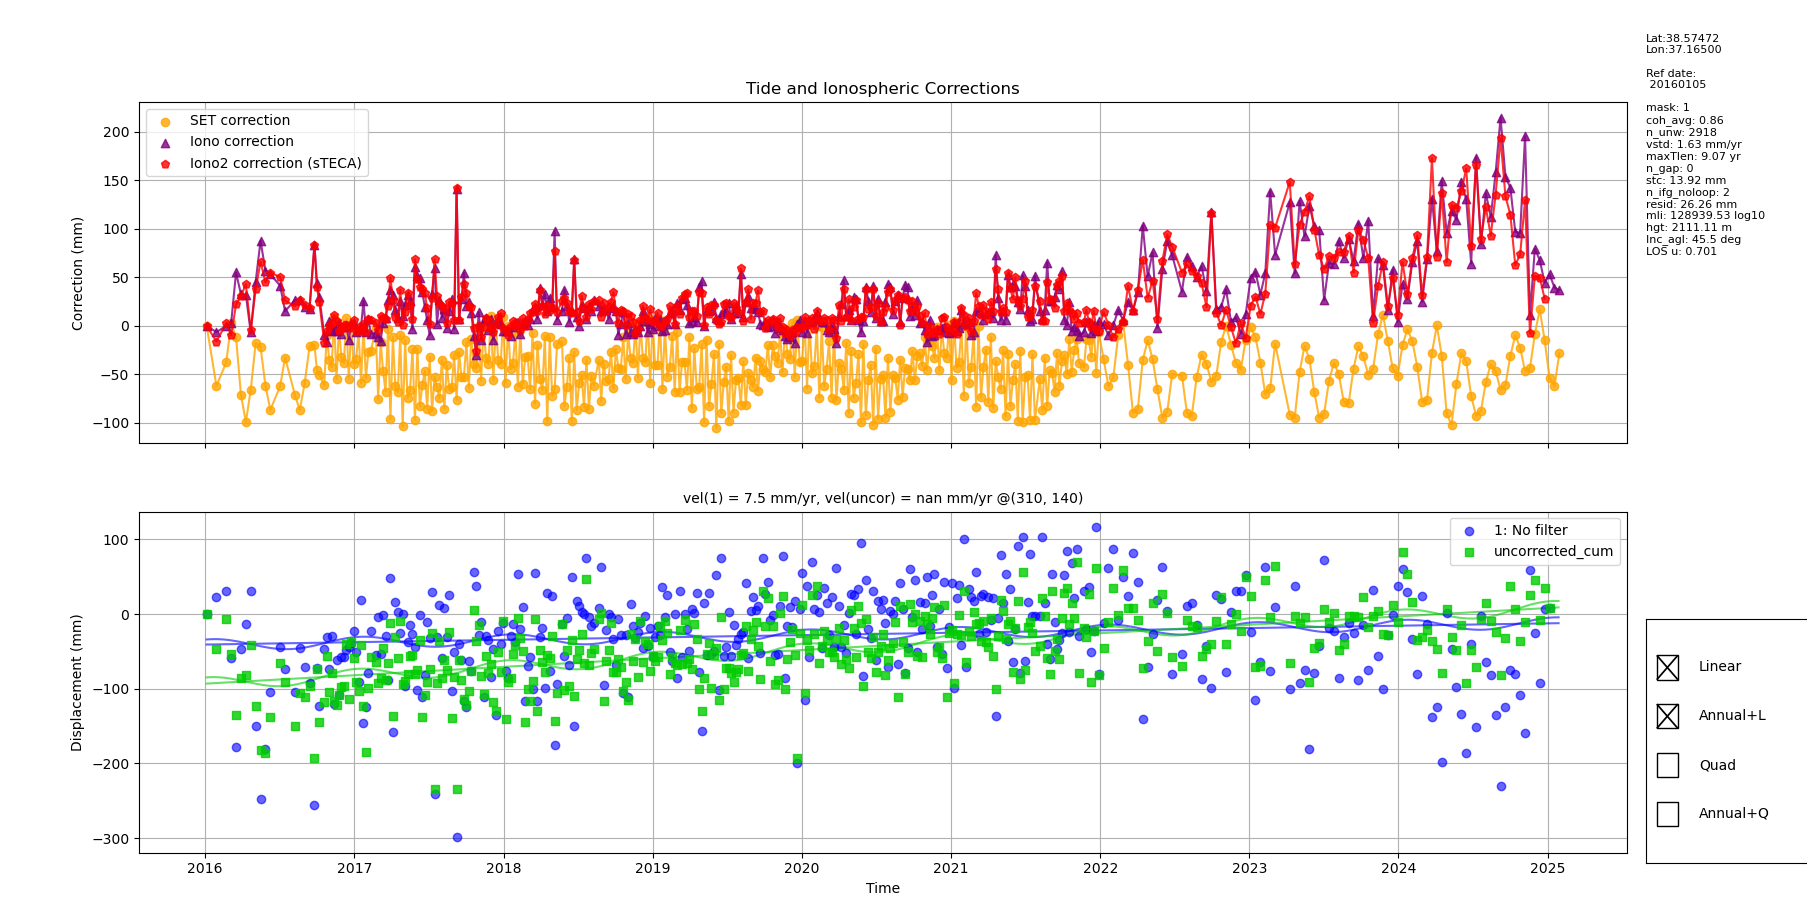

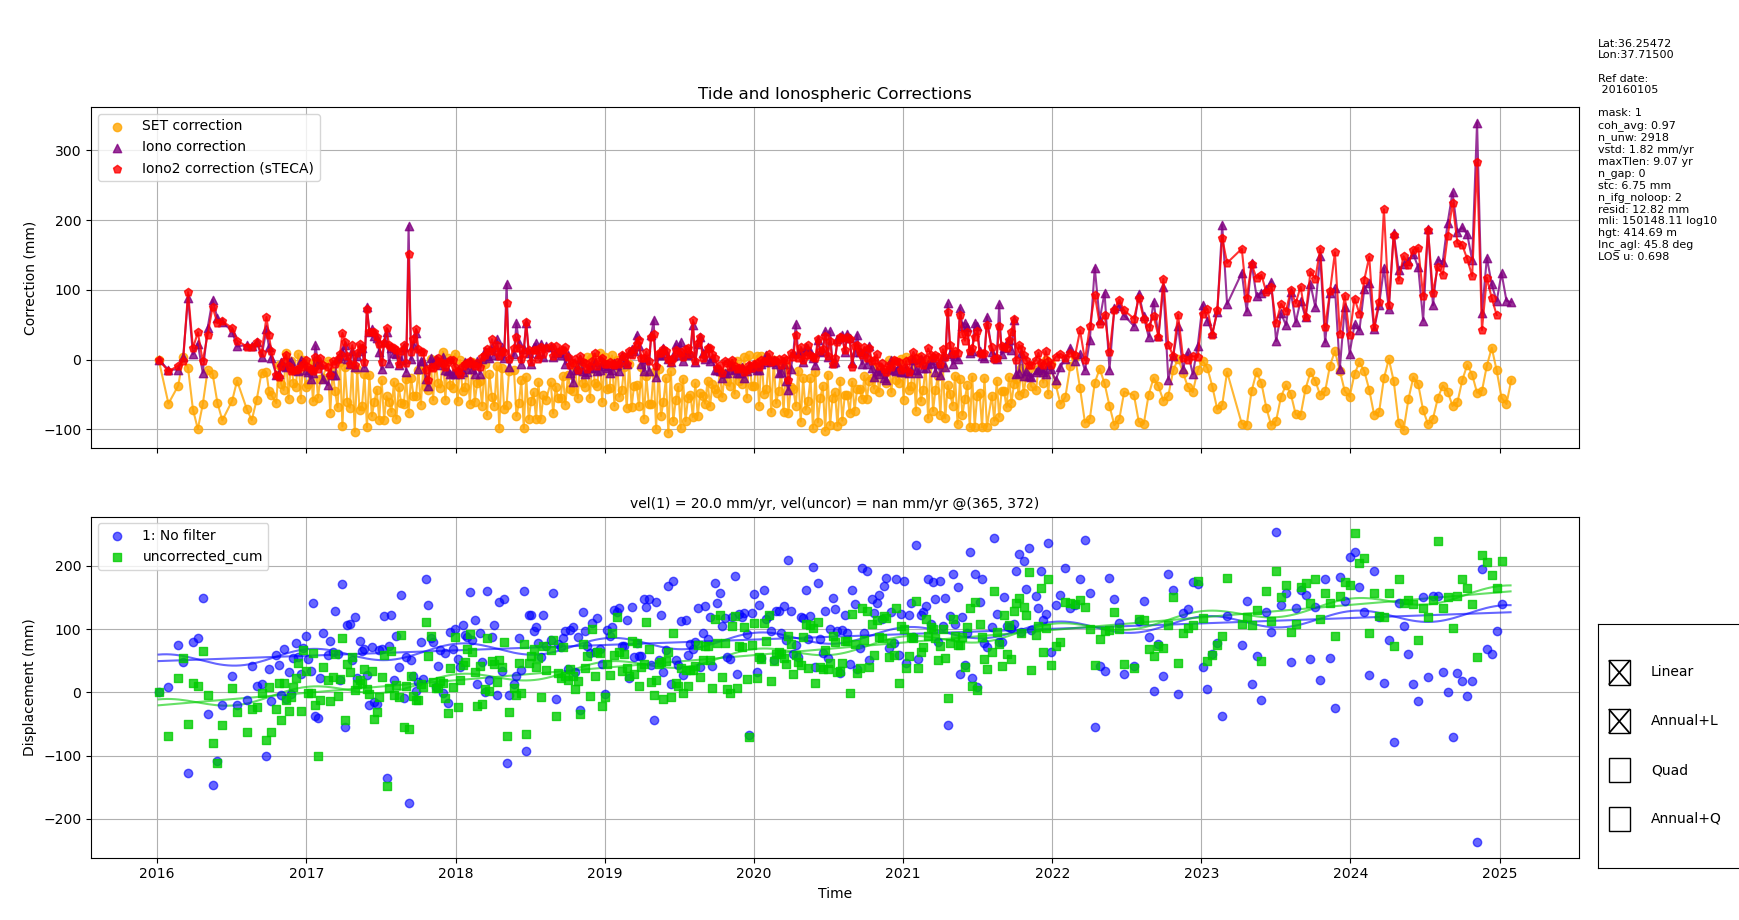

In [19]:
from IPython.display import Image, display

# Show both images
display(Image(filename='a.png'))
display(Image(filename='b.png'))
